## Assignment 3: $k$ Nearest Neighbor


**Q1.**
1. What is the difference between regression and classification?
2. What is a confusion table? What does it help us understand about a model's performance?
3. What does the SSE quantify about a particular model?
4. What are overfitting and underfitting?
5. Why does splitting the data into training and testing sets, and choosing $k$ by evaluating accuracy or SSE on the test set, improve model performance?
6. With classification, we can report a class label as a prediction or a probability distribution over class labels. Please explain the strengths and weaknesses of each approach.

**Q2.** This is a case study on $k$ nearest neighbor classification, using the `land_mines.csv` data.

The data consists of a label, `mine_type`, taking integer values 1 to 5, and three properties of the mine, `voltage`, `height` and `soil`. We want to predict the kind of mine from data about it. Imagine working for the DOD or a humanitarian aid agency, trying to help people remove land mines more safely.

1. Load the data. Perform some EDA, summarizing the target label and the features.
2. Split the sample 50/50 into training and test/validation sets. (The smaller the data are, the more equal the split should be, in my experience: Otherwise, all of the members of one class end up in the training or test data, and the model falls apart.)
3. Build a $k$-NN classifier. Explain how you select $k$.
4. Print a confusion table for the optimal model, comparing predicted and actual class label on the test set. How accurate is it? Where is performance more or less accurate?
5. Notice that you can have a lot of accurate predictions for a given type of mine, but still make a lot of mistakes. Please explain how you'd advise someone to actually use this predictive model in practice, given the errors that it tends to make.

---

## *Phase 1: Solution without AI

Complete all questions in the following cells without generative AI. Then commit and push the
notebook before beginning Phase 2.

**Declaration:** I completed this version without generative AI.

**Student(s):** Lani Le

**Date:** 9/30/26

In [ ]:
# Your Phase 1 solution to the problem goes here.

1. Regression is used for predicting a numerical target with averages, while classification is used for predicting a categorical target with majority vote.
2. A confusion table is a matrix that displays whether the predictions from a model were actually true or not. It helps us understand the accuracy and precision of a model's performance based on whether and how many were correctly predicted or incorrectly predicted.
3. The SSE quantifies the total error from a model's predictions. The SSE works by squaring each residual, the difference of the actual value and predicted value, and sums them all up, hence why it is called the Sum of Sqaured Errors. Squaring each residual, will remove the sign from the residual since it will make it positive, and it will also make it so that larger residual values will have a greater impact than smaller ones.
4. Overfitting is when the model is too flexible and it memorizes the specific randomness of training data and continues following that specific trend. Underfitting is when the model is too simple that is does not accurately capture the trend of the set of data.
5. By splitting the data into training and testing sets, we can use the training set to create a model and then, we can use the model on the test set to cross check and see how well the model performs with predicting new observations.
6. Reporting a class label is very simple so it would not require a lot of memory space, but it would have a lot less information. Reporting a probability distribution allows us to see the confidence level of the predictions, but it would take a lot more memory space to do all this, especially if the dataset was very large."

In [15]:
print('-------------------- Question 1 --------------------')

#importing packages
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split # importing function to split data
from sklearn.preprocessing import MinMaxScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix

# loading the file in
df = pd.read_csv('land_mines.csv')


-------------------- Question 1 --------------------


In [16]:
df.describe() # provides info like mean, std, quartiles, min, and max

,voltage,height,soil,mine_type
count,338.000000,338.000000,338.000000,338.000000
mean,0.430634,0.508876,0.503550,2.952663
std,0.195819,0.306043,0.344244,1.419703
min,0.197734,0.000000,0.000000,1.000000
25%,0.309737,0.272727,0.200000,2.000000
50%,0.359516,0.545455,0.600000,3.000000
75%,0.482628,0.727273,0.800000,4.000000
max,0.999999,1.000000,1.000000,5.000000


In [17]:
# checking for missing values
print(df.isnull().sum()) # checking each individual column for missing values
# there are no missing values

voltage      0
height       0
soil         0
mine_type    0
dtype: int64


[Text(0.5, 1.0, 'Mine Type vs. Soil'),
 Text(0.5, 0, 'Mine Type'),
 Text(0, 0.5, 'Soil Value')]

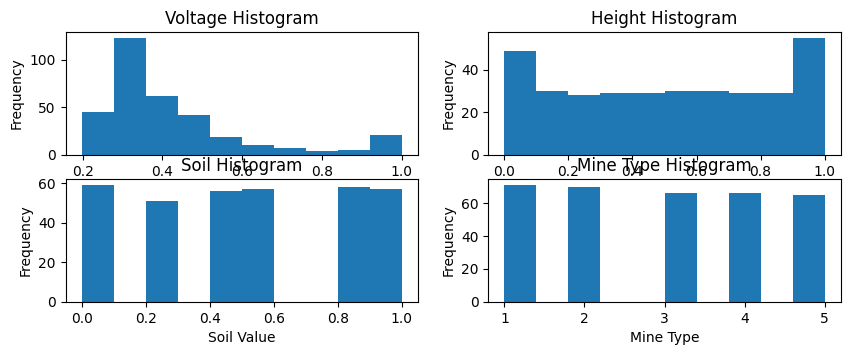

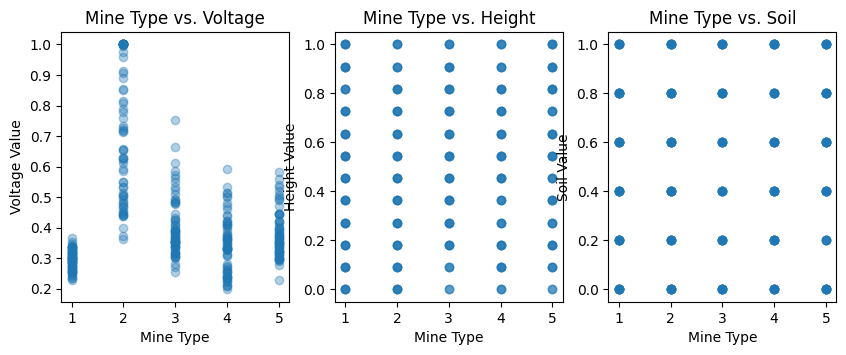

In [18]:
# plotting histograms for each variable
fig, axes = plt.subplots(2, 2, figsize=(10, 3.5))

df['voltage'].plot.hist(ax=axes[0,0])
axes[0,0].set(title='Voltage Histogram', xlabel='Voltage Value')

df['height'].plot.hist(ax=axes[0,1])
axes[0,1].set(title='Height Histogram', xlabel='Height Value')


df['soil'].plot.hist(ax=axes[1,0])
axes[1,0].set(title='Soil Histogram', xlabel='Soil Value')

df['mine_type'].plot.hist(ax=axes[1,1])
axes[1,1].set(title='Mine Type Histogram', xlabel='Mine Type')


# plotting scatterplots
fig, axes = plt.subplots(1, 3, figsize=(10, 3.5))

axes[0].scatter(df['mine_type'], df['voltage'], alpha=0.35)
axes[0].set(title='Mine Type vs. Voltage', xlabel = 'Mine Type', ylabel='Voltage Value')

axes[1].scatter(df['mine_type'], df['height'], alpha=0.35)
axes[1].set(title='Mine Type vs. Height', xlabel = 'Mine Type', ylabel='Height Value')

axes[2].scatter(df['mine_type'], df['soil'], alpha=0.35)
axes[2].set(title='Mine Type vs. Soil', xlabel = 'Mine Type', ylabel='Soil Value')


In [19]:
print('Findings: \n - 4 variables: voltage, height, soil, and mine type \n - target label is mine type \n - 0 missing values \n - information on mean, std, quartiles, min, and max can be found from the .describe() function \n - volage histogram was right skewed \n - not much skew in soil and height histograms \n - on the scatterplots for Mine Type vs. Height and Mine Type vs. Soil, the datapoints look evenly spread \n - scatterplot for Mine Type vs. Voltage has clusters')

Findings: 
 - 4 variables: voltage, height, soil, and mine type 
 - target label is mine type 
 - 0 missing values 
 - information on mean, std, quartiles, min, and max can be found from the .describe() function 
 - volage histogram was right skewed 
 - not much skew in soil and height histograms 
 - on the scatterplots for Mine Type vs. Height and Mine Type vs. Soil, the datapoints look evenly spread 
 - scatterplot for Mine Type vs. Voltage has clusters


In [20]:
print('-------------------- Question 2 --------------------')
eval_X_raw = df[['voltage', 'height', 'soil']]
eval_y = df['mine_type']

# splitting the sample 50/50 into training and test/validation sets
(
    eval_X_train_raw,
    eval_X_valid_raw,
    eval_y_train,
    eval_y_valid,
) = train_test_split(
    eval_X_raw, eval_y, test_size=0.50, random_state=65, stratify=eval_y
)

# fitting the scalar
eval_scaler = MinMaxScaler()
eval_X_train_scaled = pd.DataFrame(eval_scaler.fit_transform(eval_X_train_raw))
eval_X_valid_scaled = pd.DataFrame(eval_scaler.transform(eval_X_valid_raw))

# viewing split samples
eval_X_train_scaled.head()

-------------------- Question 2 --------------------


,0,1,2
0,0.408781,0.272727,0.2
1,0.053400,0.636364,0.0
2,0.385895,0.090909,0.2
3,0.032879,0.727273,0.4
4,0.088378,0.272727,0.0


In [21]:
eval_X_valid_scaled.head()

,0,1,2
0,1.000000,0.181818,0.6
1,0.343937,0.454545,0.2
2,0.141778,0.090909,0.0
3,0.084564,0.454545,0.2
4,0.412595,0.000000,0.2


In [22]:
print('-------------------- Question 3 --------------------')

eval_ks = np.arange(1, 51)
eval_valid_sse = []
eval_train_sse = []
for eval_k in eval_ks:
    eval_candidate = KNeighborsClassifier(n_neighbors=int(eval_k))
    eval_candidate.fit(eval_X_train_scaled, eval_y_train)
    eval_valid_hat = eval_candidate.predict(eval_X_valid_scaled)
    eval_train_hat = eval_candidate.predict(eval_X_train_scaled)
    eval_valid_sse.append(np.sum(
        (eval_y_valid.to_numpy() - eval_valid_hat) ** 2
    ))
    eval_train_sse.append(np.sum(
        (eval_y_train.to_numpy() - eval_train_hat) ** 2
    ))
eval_k_star = int(eval_ks[np.argmin(eval_valid_sse)])

print('Validation SSE is lowest at k =', eval_k_star)
print('I selected k by looping through all the values of k from 1 to 50 and then generating predictions and calculating the SSE. I chose the k value that has the lowest SSE.')

-------------------- Question 3 --------------------
Validation SSE is lowest at k = 2
I selected k by looping through all the values of k from 1 to 50 and then generating predictions and calculating the SSE. I chose the k value that has the lowest SSE.


In [23]:
print('-------------------- Question 4 --------------------')
best_knn = KNeighborsClassifier(n_neighbors=eval_k_star)
best_knn.fit(eval_X_train_scaled, eval_y_train)

eval_valid_preds = np.clip(np.round(best_knn.predict(eval_X_valid_scaled)), 1, 5)
print('Confusion Matrix:')
print(confusion_matrix(eval_y_valid, eval_valid_preds))

correct_predictions = np.sum(eval_y_valid.to_numpy() == eval_valid_preds)
total_samples = len(eval_y_valid)
eval_test_acc = correct_predictions / total_samples

print('\n Validation Accuracy: ', eval_test_acc)
print("From the Confusion Matrix, we can see that the model's performance is most accurate for Mine Type 2, as it had 31 correct predictions, which was the highest amount.")
print("Performance was less accurate for Type 3, 4, and 5, but specifically Type 5, where  it only predicted 2 correctly.")

-------------------- Question 4 --------------------
Confusion Matrix:
[[27  0  5  2  2]
 [ 0 31  2  1  1]
 [10  2 10 10  1]
 [15  6  3  9  0]
 [15  0 10  5  2]]

 Validation Accuracy:  0.46745562130177515
From the Confusion Matrix, we can see that the model's performance is most accurate for Mine Type 2, as it had 31 correct predictions, which was the highest amount.
Performance was less accurate for Type 3, 4, and 5, but specifically Type 5, where  it only predicted 2 correctly.


In [ ]:
print('-------------------- Question 5 --------------------')
print('Because there is still chance for a lot of mistakes using a model to make predictions, people should use these predictive models with caution, making sure to consider how accurate it was from the confusion matrix. For example, because Type 2 was pretty accurate that can likely be used to predict values, but the other Types, not so much There should also probably be a confidence interval that go with these predictions.')

-------------------- Question 5 --------------------
Because there is still chance for a lot of mistakes using a model to make predictions, people should use these predictive models with caution, making sure to consider how accurate it was from the confusion matrix. For example, because Type 2 was pretty accurate that can likely be used to predict values, but the other Types, not so much There should also probably be a confidence interval that go with these predictions.


## *Phase 2: AI-assisted Revision
Keep Phase 1 frozen.

- **Phase 1 commit SHA ID:** 46083c887dd5a0c5c5e19ea9c309c39bef8e7cf2
- **AI tool and model used:** ChatGPT, GPT=5.6 Luna

### *Prompts used

1. Please improve my code and make sure hits all instructions asked for in Question 1 and 2.
2. [Paste follow-up prompt]

### *AI-proposed changes


[Paste the AI's concise numbered list verbatim.]

1. Improve the Q1 explanations, especially the distinction between classification and regression, the meaning of a confusion matrix, SSE, overfitting/underfitting, validation versus test data, and class labels versus probability distributions.
2. Perform clearer EDA for the land-mine data, including dimensions, data types, missing values, descriptive statistics, target-class counts, and feature distributions.
3. Use a stratified 50/50 train/validation split so all five mine types are represented in both sets.
4. Scale the three predictor variables using parameters fit only on the training data.
5. Select k by validation accuracy rather than clipping/rounding predictions or treating class labels as continuous values. Evaluate k = 1 through 50 and use the smallest k in case of a tie.
7. Report a clearly labeled confusion matrix with actual classes as rows and predicted classes as columns, along with overall accuracy and per-class precision/recall.
8. Explain the practical implications of false negatives and class-specific errors and emphasize that this model should not be treated as a standalone safety decision tool.

### *Evaluation of AI suggestions


| Change | Decision | Reason and verification |
|---|---|---|
| 1 | Reject | My original responses to the first part seem pretty similar to the AI's responses, but the AI's responses do go more in depth. However, it does talk about additional detail that we have not gone over in class, so I believe that my own response focus moreso on the specifics of what we need to know about these topics in class. |
| 2 | Accept | The AI only added more to my exploratory data analysis, using additional functions to look at the shape, data types, ranges, and etc. It also made my graphs cleaner and neater. |
| 3 | Accept | The AI incorporates stratification into the splitting. By doing so, it help prevent the problem that the the directions specified, where "Otherwise, all of the members of one class end up in the training or test data, and the model falls apart". |
| 4 | Reject | This was more of a comment rather than a necessary change because my original code already scaled the the predictor variables using the training data. I also followed the format of scaling from the lecture slides, so the scaling was already implemented as intended. |
| 5 | Accept | Since the variable mine_type is a a qualitative data type, rather than using SSE, I need to use validation accuracy to select k, which the AI suggested. |
| 6 | Accept | This change is just the AI adding labels to the rows and columns in the confusion table, making it easier to follow and understand. |
| 7 | Accept | This suggestion from the AI just adds further explanation into my response for the last question.

### *AI-assisted solution in full
After the evaluation of AI suggestions, incorporate the accepted revisions into your Phase 1 solution and provide the final Phase 2 solution in full in the following cells.

-------------------- Question 1 --------------------
Shape: (338, 4)

Data types:
voltage      float64
height       float64
soil         float64
mine_type      int64
dtype: object

Missing values:
voltage      0
height       0
soil         0
mine_type    0
dtype: int64

Descriptive statistics:


,voltage,height,soil,mine_type
count,338.000000,338.000000,338.000000,338.000000
mean,0.430634,0.508876,0.503550,2.952663
std,0.195819,0.306043,0.344244,1.419703
min,0.197734,0.000000,0.000000,1.000000
25%,0.309737,0.272727,0.200000,2.000000
50%,0.359516,0.545455,0.600000,3.000000
75%,0.482628,0.727273,0.800000,4.000000
max,0.999999,1.000000,1.000000,5.000000



Mine-type counts:
mine_type
1    71
2    70
3    66
4    66
5    65
Name: count, dtype: int64

Feature ranges:
              min       max      mean       std
voltage  0.197734  0.999999  0.430634  0.195819
height   0.000000  1.000000  0.508876  0.306043
soil     0.000000  1.000000  0.503550  0.344244


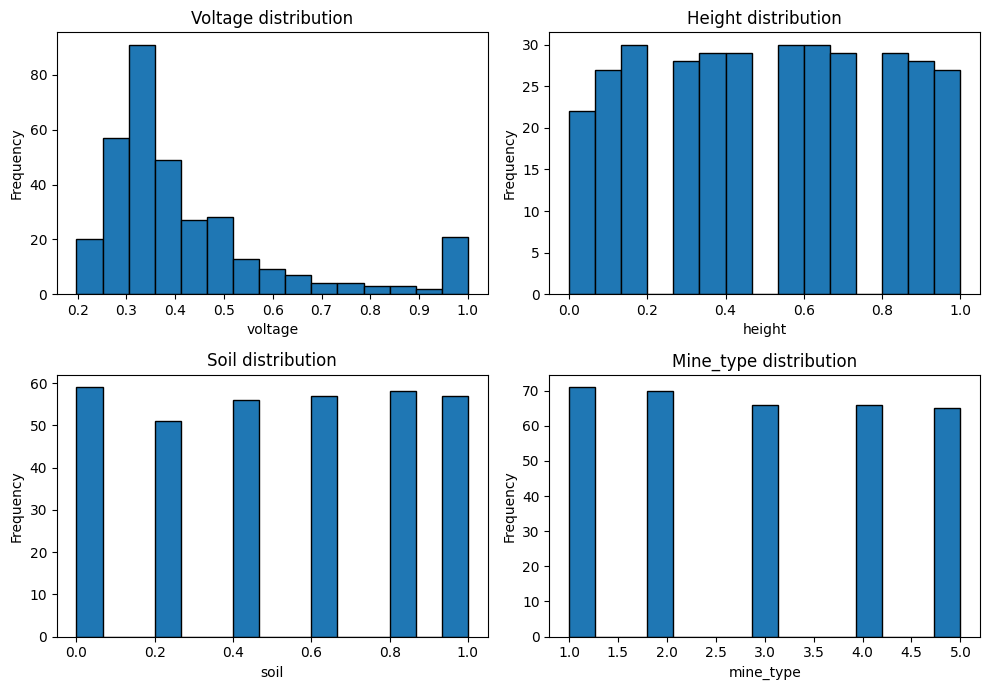

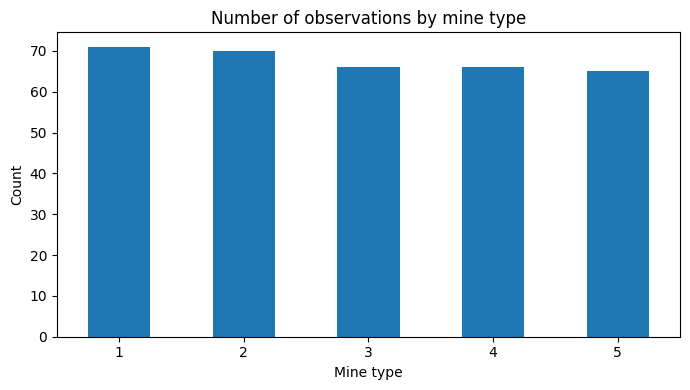

-------------------- Question 2 --------------------
Training observations: 169
Validation observations: 169

Training class counts:
mine_type
1    35
2    35
3    33
4    33
5    33
Name: count, dtype: int64

Validation class counts:
mine_type
1    36
2    35
3    33
4    33
5    32
Name: count, dtype: int64
-------------------- Question 3 --------------------
Candidate k values: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50]
Selected k: 2
Best validation accuracy: 0.4675
Selection rule: choose the k with the highest validation accuracy; if tied, choose the smaller k.


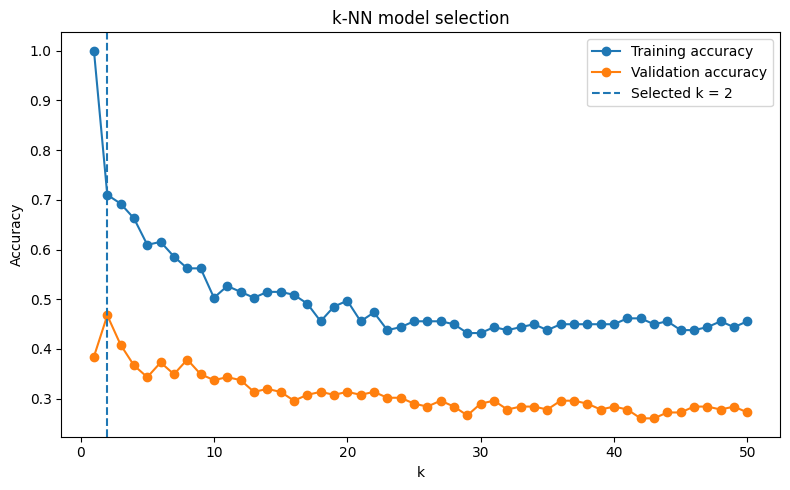

-------------------- Question 4 --------------------
Confusion table:


,Predicted 1,Predicted 2,Predicted 3,Predicted 4,Predicted 5
Actual 1,27,0,5,2,2
Actual 2,0,31,2,1,1
Actual 3,10,2,10,10,1
Actual 4,15,6,3,9,0
Actual 5,15,0,10,5,2


Overall validation accuracy: 0.4675

Per-class performance:


,precision,recall,f1-score,support
Mine type 1,0.403,0.750,0.524,36.0
Mine type 2,0.795,0.886,0.838,35.0
Mine type 3,0.333,0.303,0.317,33.0
Mine type 4,0.333,0.273,0.300,33.0
Mine type 5,0.333,0.062,0.105,32.0



Interpretation:
- The diagonal of the confusion table contains correct predictions.
- Off-diagonal cells show which mine types are being confused with one another.
- Recall answers: among observations that were actually a given mine type, how
  many did the model identify as that type?
- Precision answers: among observations predicted to be a given mine type, how
  many actually belonged to that type?
- Therefore, overall accuracy alone does not describe the model equally well
  for every mine type.

-------------------- Question 5 --------------------

The model should be treated as a supporting classification tool rather than as
a standalone system for deciding whether a physical object is safe to approach
or remove. The confusion table shows that performance differs substantially by
mine type: some classes are identified much more reliably than others, and some
observations are repeatedly confused across classes.

In a safety-critical setting, these errors matter because a wrong cl

In [24]:
# Your Phase 2 solution to the problem goes here.

print('-------------------- Question 1 --------------------')

# Q2.1: Load data and EDA

from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

data = pd.read_csv("land_mines.csv")

print("Shape:", data.shape)
print("\nData types:")
print(data.dtypes)
print("\nMissing values:")
print(data.isnull().sum())
print("\nDescriptive statistics:")
display(data.describe())

print("\nMine-type counts:")
print(data["mine_type"].value_counts().sort_index())

feature_cols = ["voltage", "height", "soil"]
target_col = "mine_type"

print("\nFeature ranges:")
print(data[feature_cols].agg(["min", "max", "mean", "std"]).T)

# Histograms for all variables
fig, axes = plt.subplots(2, 2, figsize=(10, 7))
for ax, col in zip(axes.ravel(), feature_cols + [target_col]):
    ax.hist(data[col], bins=15, edgecolor="black")
    ax.set_title(f"{col.capitalize()} distribution")
    ax.set_xlabel(col)
    ax.set_ylabel("Frequency")
plt.tight_layout()
plt.show()

# Class counts
data["mine_type"].value_counts().sort_index().plot(kind="bar", figsize=(7, 4))
plt.title("Number of observations by mine type")
plt.xlabel("Mine type")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

print('-------------------- Question 2 --------------------')

# Q2.2: 50/50 stratified split

X = data[feature_cols]
y = data[target_col]

X_train, X_valid, y_train, y_valid = train_test_split(
    X,
    y,
    test_size=0.50,
    random_state=65,
    stratify=y
)

print("Training observations:", len(X_train))
print("Validation observations:", len(X_valid))

print("\nTraining class counts:")
print(y_train.value_counts().sort_index())

print("\nValidation class counts:")
print(y_valid.value_counts().sort_index())

print('-------------------- Question 3 --------------------')

# Q2.3: Scale and select k

# Fit the scaler ONLY on the training set.
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_valid_scaled = scaler.transform(X_valid)

k_values = range(1, 51)
train_accuracy = []
valid_accuracy = []

for k in k_values:
    model = KNeighborsClassifier(n_neighbors=k)
    model.fit(X_train_scaled, y_train)

    train_pred = model.predict(X_train_scaled)
    valid_pred = model.predict(X_valid_scaled)

    train_accuracy.append(accuracy_score(y_train, train_pred))
    valid_accuracy.append(accuracy_score(y_valid, valid_pred))

results = pd.DataFrame({
    "k": list(k_values),
    "training_accuracy": train_accuracy,
    "validation_accuracy": valid_accuracy
})

# Select the k with the highest validation accuracy.
# If there is a tie, choose the smaller k.
best_validation_accuracy = results["validation_accuracy"].max()
best_k = int(
    results.loc[
        results["validation_accuracy"] == best_validation_accuracy, "k"
    ].min()
)

print("Candidate k values:", list(k_values))
print("Selected k:", best_k)
print("Best validation accuracy:", round(best_validation_accuracy, 4))
print(
    "Selection rule: choose the k with the highest validation accuracy; "
    "if tied, choose the smaller k."
)

plt.figure(figsize=(8, 5))
plt.plot(results["k"], results["training_accuracy"], marker="o", label="Training accuracy")
plt.plot(results["k"], results["validation_accuracy"], marker="o", label="Validation accuracy")
plt.axvline(best_k, linestyle="--", label=f"Selected k = {best_k}")
plt.xlabel("k")
plt.ylabel("Accuracy")
plt.title("k-NN model selection")
plt.legend()
plt.tight_layout()
plt.show()

print('-------------------- Question 4 --------------------')

# Q2.4: Final selected model

best_knn = KNeighborsClassifier(n_neighbors=best_k)
best_knn.fit(X_train_scaled, y_train)

valid_predictions = best_knn.predict(X_valid_scaled)

classes = [1, 2, 3, 4, 5]
cm = confusion_matrix(y_valid, valid_predictions, labels=classes)

confusion_table = pd.DataFrame(
    cm,
    index=[f"Actual {c}" for c in classes],
    columns=[f"Predicted {c}" for c in classes]
)

print("Confusion table:")
display(confusion_table)

overall_accuracy = accuracy_score(y_valid, valid_predictions)
print("Overall validation accuracy:", round(overall_accuracy, 4))

report = classification_report(
    y_valid,
    valid_predictions,
    labels=classes,
    target_names=[f"Mine type {c}" for c in classes],
    output_dict=True,
    zero_division=0
)

per_class = pd.DataFrame(report).T.loc[
    [f"Mine type {c}" for c in classes],
    ["precision", "recall", "f1-score", "support"]
]

print("\nPer-class performance:")
display(per_class.round(3))

print("""
Interpretation:
- The diagonal of the confusion table contains correct predictions.
- Off-diagonal cells show which mine types are being confused with one another.
- Recall answers: among observations that were actually a given mine type, how
  many did the model identify as that type?
- Precision answers: among observations predicted to be a given mine type, how
  many actually belonged to that type?
- Therefore, overall accuracy alone does not describe the model equally well
  for every mine type.
""")

print('-------------------- Question 5 --------------------')

# Q2.5: Practical use

print("""
The model should be treated as a supporting classification tool rather than as
a standalone system for deciding whether a physical object is safe to approach
or remove. The confusion table shows that performance differs substantially by
mine type: some classes are identified much more reliably than others, and some
observations are repeatedly confused across classes.

In a safety-critical setting, these errors matter because a wrong classification
could lead to an unsafe decision. In particular, the model's false negatives
(when an observation from a class is assigned to another class) should not be
treated as harmless. A practical workflow would therefore use the model to
provide information for trained personnel, combine it with validated detection
methods and other available evidence, and require an appropriate safety protocol
before any physical action is taken.

The validation accuracy also does not guarantee the same performance in a new
location or with different sensor/data conditions. Before deployment, the model
would need additional external validation and monitoring on representative data.
""")


### *Reflection on AI assistance
In your own words without generative AI.

[In 150–300 words, describe the main improvements, AI mistakes or limitations, how the final solution was verified, and any remaining concerns.]

The AI mainly focused on assuring that the code correctly executed the instructional directions. I did not do the k-selection entirely correct, because I used SSE instead of validation accurary, so the AI implemented that fix so that my code accurately presented the correct results and findings. It also focused on improving the cleaniness of the code, and modeled graphs and tables. My histograms were a little hard to follow which text overlapping each other, so it fixed that and also my confusion table was missing some labels, which could make it hard for someone looking at the code for the first time to completely understand. A limitation of the AI was that it would sometimes overcomplicate ideas or processes. For example, for the first part where I was responding to the questions, I utilized the lectures slides to find information to answer the questions, while the AI's answer might be a little harder to follow because it is not as simple and to the point. I first evaluated all the suggestions to see whether I wanted to accept, modify, or reject the changes. Then, I verified the code by running the new solution with the accepted AI's changes and made sure it was printing out and displaying all requiremnts and still answering all the questions. I also verified that the AI did not add any unnescesarry changes to the code.